# SA3. Agrupacion - cliente_tienda.csv

Segmentacion de clientes con **K-Means**, usando ingresos anuales y porcentaje de gasto: la dispersion de estas dos variables muestra grupos geometricamente separados y razonablemente esfericos, la estructura que K-Means detecta mejor.

## 1. Carga de datos

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json, joblib, os

df = pd.read_csv('cliente_tienda.csv')
print(df.shape)
print(df.isnull().sum())
df.head()


(200, 5)
CustomerID                       0
Genero                           0
Edad                             0
Ingresos Anuales ($)             0
Porcentajde de gastos (1-100)    0
dtype: int64


,CustomerID,Genero,Edad,Ingresos Anuales ($),Porcentajde de gastos (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


## 2. Seleccion de variables de agrupacion

In [2]:
# Se excluye CustomerID (identificador) y Genero (categorica no ordinal).
# Edad se conserva solo como variable descriptiva para el perfil de clusters.
cols_cluster = ['Ingresos Anuales ($)', 'Porcentajde de gastos (1-100)']
X_raw = df[cols_cluster]
X_raw.describe()


,Ingresos Anuales ($),Porcentajde de gastos (1-100)
count,200.000000,200.000000
mean,60.560000,50.200000
std,26.264721,25.823522
min,15.000000,1.000000
25%,41.500000,34.750000
50%,61.500000,50.000000
75%,78.000000,73.000000
max,137.000000,99.000000


## 3. Comportamiento de los datos (antes de aplicar el algoritmo)

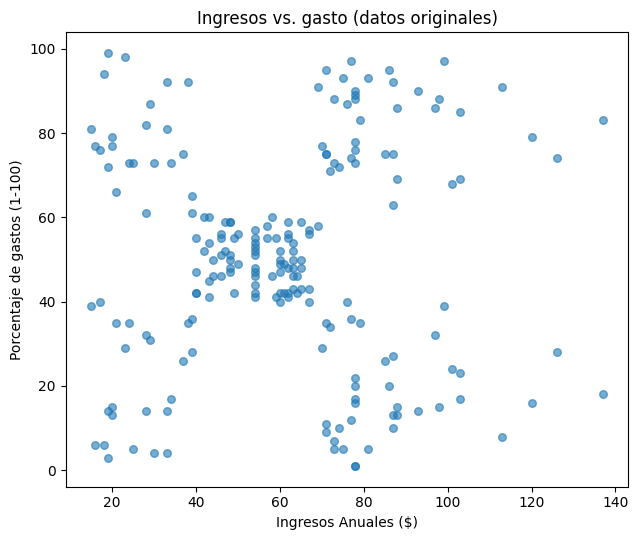

In [3]:
plt.figure(figsize=(6.5, 5.5))
plt.scatter(df['Ingresos Anuales ($)'], df['Porcentajde de gastos (1-100)'], alpha=0.6, s=30)
plt.xlabel('Ingresos Anuales ($)')
plt.ylabel('Porcentaje de gastos (1-100)')
plt.title('Ingresos vs. gasto (datos originales)')
plt.tight_layout()
plt.show()


## 4. Estandarizacion de variables

In [4]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)
X_scaled[:5]


array([[-1.73899919, -0.43480148],
       [-1.73899919,  1.19570407],
       [-1.70082976, -1.71591298],
       [-1.70082976,  1.04041783],
       [-1.66266033, -0.39597992]])

## 5. Optimizacion de k (metodo del codo + silhouette, k=2..8)

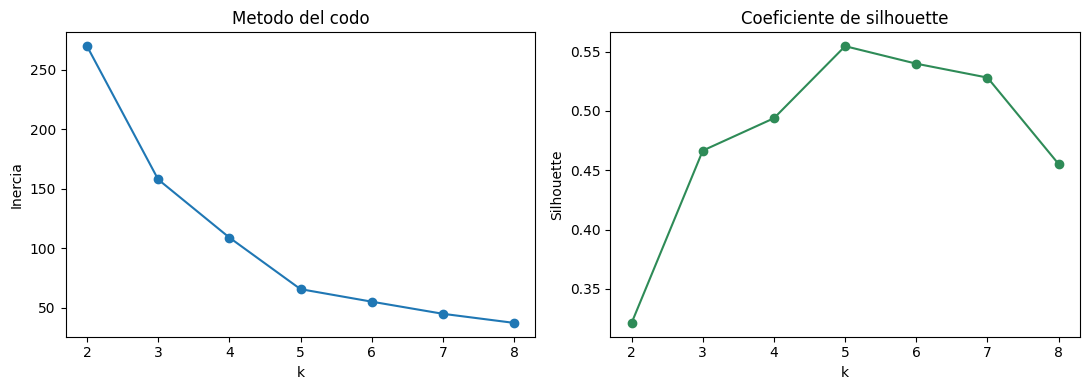

k=2: silhouette=0.321
k=3: silhouette=0.467
k=4: silhouette=0.494
k=5: silhouette=0.555
k=6: silhouette=0.540
k=7: silhouette=0.528
k=8: silhouette=0.455


In [5]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

inertias = []
silhouettes = []
ks = range(2, 9)
for k in ks:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(list(ks), inertias, 'o-')
axes[0].set_xlabel('k'); axes[0].set_ylabel('Inercia'); axes[0].set_title('Metodo del codo')
axes[1].plot(list(ks), silhouettes, 'o-', color='seagreen')
axes[1].set_xlabel('k'); axes[1].set_ylabel('Silhouette'); axes[1].set_title('Coeficiente de silhouette')
plt.tight_layout()
plt.show()

for k, s in zip(ks, silhouettes):
    print(f'k={k}: silhouette={s:.3f}')


## 6. Modelo final con k optimo

In [6]:
k_optimo = 5
kmeans = KMeans(n_clusters=k_optimo, random_state=42, n_init=10)
df['cluster'] = kmeans.fit_predict(X_scaled)
sil_final = silhouette_score(X_scaled, df['cluster'])

print('k optimo:', k_optimo)
print('Coeficiente de silhouette:', round(sil_final, 3))
print('Tamano de clusters:')
print(df['cluster'].value_counts().sort_index())


k optimo: 5
Coeficiente de silhouette: 0.555
Tamano de clusters:
cluster
0    81
1    39
2    22
3    35
4    23
Name: count, dtype: int64


## 7. Visualizacion de los clusters y centroides

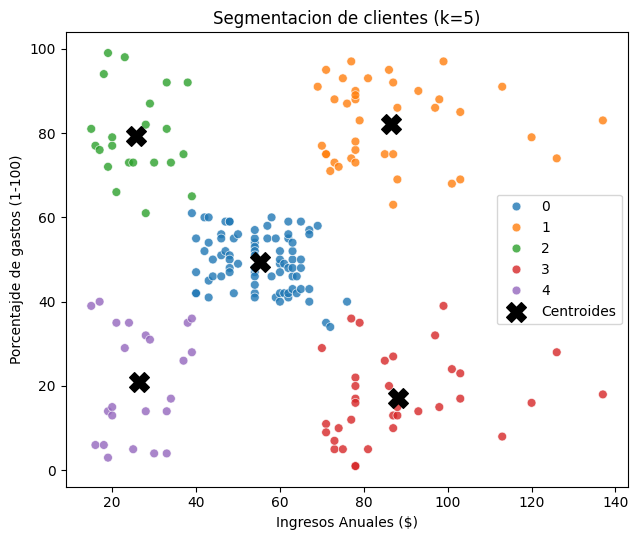

In [7]:
centroides_originales = scaler.inverse_transform(kmeans.cluster_centers_)

plt.figure(figsize=(6.5, 5.5))
sns.scatterplot(data=df, x='Ingresos Anuales ($)', y='Porcentajde de gastos (1-100)',
                 hue='cluster', palette='tab10', s=40, alpha=0.8)
plt.scatter(centroides_originales[:, 0], centroides_originales[:, 1],
            marker='X', s=200, c='black', label='Centroides')
plt.title(f'Segmentacion de clientes (k={k_optimo})')
plt.legend()
plt.tight_layout()
plt.show()


## 8. Perfil demografico por cluster

         ingreso_promedio  gasto_promedio  edad_promedio  n_clientes
cluster                                                             
0                    55.3            49.5           42.7          81
1                    86.5            82.1           32.7          39
2                    25.7            79.4           25.3          22
3                    88.2            17.1           41.1          35
4                    26.3            20.9           45.2          23


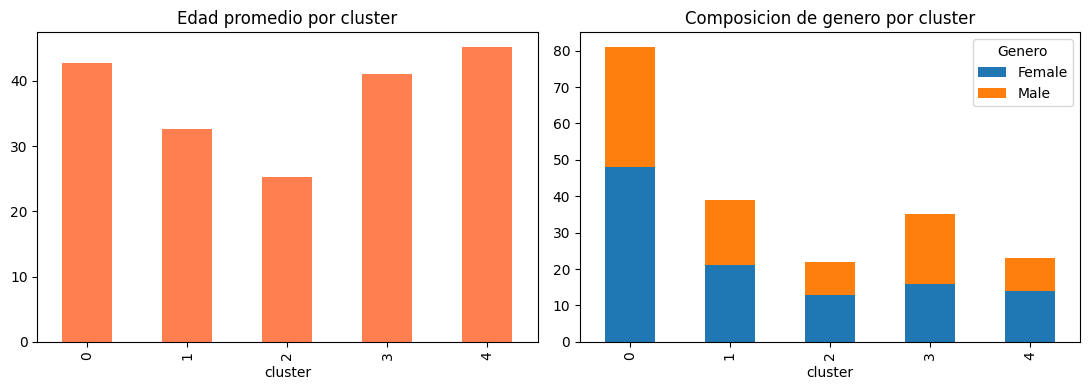

In [8]:
perfil = df.groupby('cluster').agg(
    ingreso_promedio=('Ingresos Anuales ($)', 'mean'),
    gasto_promedio=('Porcentajde de gastos (1-100)', 'mean'),
    edad_promedio=('Edad', 'mean'),
    n_clientes=('CustomerID', 'count')
).round(1)
print(perfil)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
perfil['edad_promedio'].plot(kind='bar', ax=axes[0], color='coral')
axes[0].set_title('Edad promedio por cluster')
df.groupby(['cluster', 'Genero']).size().unstack().plot(kind='bar', stacked=True, ax=axes[1])
axes[1].set_title('Composicion de genero por cluster')
plt.tight_layout()
plt.show()


## 9. Guardado del modelo y de las metricas

In [9]:
os.makedirs('modelo', exist_ok=True)
joblib.dump({'scaler': scaler, 'kmeans': kmeans}, 'modelo/modelo_clustering_clientes.pkl')

metrics = {
    "algoritmo": "K-Means",
    "dataset": "cliente_tienda.csv",
    "variables_agrupacion": cols_cluster,
    "mejor_hiperparametro": {"k_optimo": k_optimo},
    "metricas": {
        "coeficiente_silhouette": round(float(sil_final), 3),
        "tamano_clusters": df['cluster'].value_counts().sort_index().tolist()
    }
}
print(json.dumps(metrics, indent=2, ensure_ascii=False))
print('\nModelo guardado en modelo/modelo_clustering_clientes.pkl')


{
  "algoritmo": "K-Means",
  "dataset": "cliente_tienda.csv",
  "variables_agrupacion": [
    "Ingresos Anuales ($)",
    "Porcentajde de gastos (1-100)"
  ],
  "mejor_hiperparametro": {
    "k_optimo": 5
  },
  "metricas": {
    "coeficiente_silhouette": 0.555,
    "tamano_clusters": [
      81,
      39,
      22,
      35,
      23
    ]
  }
}

Modelo guardado en modelo/modelo_clustering_clientes.pkl
